# Explore here

## PASO 2: Explorar la API

In [ ]:
import requests

# # URL base de la API del World Bank
url = "https://api.worldbank.org/v2/country"
# Parametros de la peticion:
params = {
    "format": "json", # Respuesta en JSON
    "per_page": 50, # Número de resultados por página
    "page": 1 # primera página
}

# Hacemos la petición a la API
response = requests.get(url, params=params, timeout=30)
# Si hay un error en la petición, lo muestra
response.raise_for_status()
# Convertimos la respuesta a JSON
payload = response.json()

# Mostramos metadatos (info de paginación)
print("Metadatos:", payload[0])
# Mostramos un ejemplo de país para ver estructura
print("Primer elemento:", payload[1][0])

Metadatos: {'page': 1, 'pages': 6, 'per_page': '50', 'total': 296}
Primer elemento: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


## PASO 3: Descargar datos

In [ ]:
import requests

# Lista de países en formato ISO3
countries = ["ARG", "AUS", "JPN", "USA", "ITA"]

# Indicadores seleccionados para el análisis
indicators = [
    "SP.POP.TOTL",          # Población total
    "SE.ADT.LITR.ZS",       # Alfabetización
    "EG.USE.ELEC.KH.PC",    # Consumo eléctrico
    "SH.XPD.CHEX.PC.CD"     # Gasto en salud
]

# Rango de años del análisis
start_year = 2010
end_year = 2024

# Lista donde guardaremos todos los datos
all_data = []

# Recorremos cada indicador
for indicator in indicators:
    
    # Construimos URL con países e indicador
    url = f"https://api.worldbank.org/v2/country/{';'.join(countries)}/indicator/{indicator}"
    
    # Parámetros de la petición
    params = {
        "format": "json",
        "date": f"{start_year}:{end_year}",
        "per_page": 1000  # pedimos muchos datos de golpe
    }
    
    # Petición a la API
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    
    # Convertimos respuesta a JSON
    data = response.json()
    
    # Si no hay datos, pasamos al siguiente indicador
    if len(data) < 2 or not data[1]:
        continue
    
    # Recorremos los registros devueltos por la API
    for entry in data[1]:
        
        # Guardamos los datos en formato estructurado
        all_data.append({
            "country": entry["country"]["value"],
            "year": entry["date"],
            "indicator": indicator,
            "value": entry["value"]
        })

# Mostramos cuántos registros hemos recogido
print("Total registros:", len(all_data))

Total registros: 300


## PASO 4: Transformar a DataFrames

In [10]:
import pandas as pd

# Convertimos la lista de diccionarios en DataFrame
df = pd.DataFrame(all_data)

# Convertimos columnas a tipo numérico para poder analizarlas
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Eliminamos valores nulos (datos incompletos de la API)
df = df.dropna(subset=["value"])

# Mostramos primeras filas del dataset limpio
df.head()

,country,year,indicator,value
0,Argentina,2024,SP.POP.TOTL,45696159.0
1,Argentina,2023,SP.POP.TOTL,45538401.0
2,Argentina,2022,SP.POP.TOTL,45407904.0
3,Argentina,2021,SP.POP.TOTL,45312281.0
4,Argentina,2020,SP.POP.TOTL,45191965.0


In [ ]:
# Creamos un DataFrame por cada indicador para analizarlos por separado
df_population = df[df["indicator"] == "SP.POP.TOTL"]          # población
df_literacy = df[df["indicator"] == "SE.ADT.LITR.ZS"]         # alfabetización
df_electricity = df[df["indicator"] == "EG.USE.ELEC.KH.PC"]   # electricidad
df_health = df[df["indicator"] == "SH.XPD.CHEX.PC.CD"]        # salud

## PASO 5: Analisis y visualizaciones

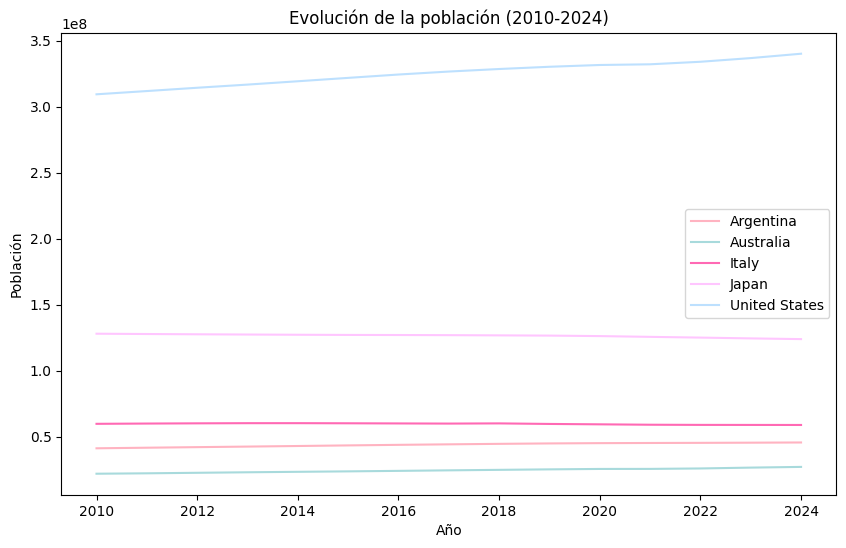

In [17]:
import matplotlib.pyplot as plt

# Paleta pastel coherente con los otros gráficos
colors = {
    "Argentina": "#ffb3c1",   # rosa suave
    "Australia": "#a8dadc",   # azul claro
    "Japan": "#ffc6ff",       # rosa claro
    "United States": "#bde0fe", # azul pastel
    "Italy": "#ff69b4"        # pink fuerte suave
}

plt.figure(figsize=(10,6))

# Recorremos cada país
for country in df_population["country"].unique():
    
    data = df_population[df_population["country"] == country]
    
    plt.plot(
        data["year"],
        data["value"],
        label=country,
        color=colors.get(country, "#cccccc")  # color por país
    )

plt.title("Evolución de la población (2010-2024)")
plt.xlabel("Año")
plt.ylabel("Población")
plt.legend()

plt.show()

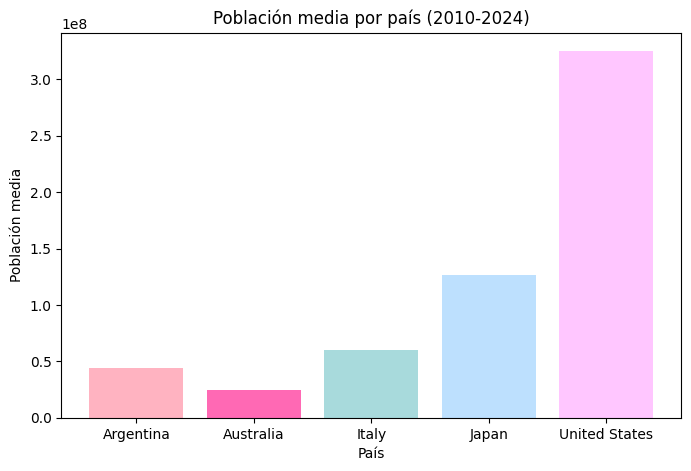

In [15]:
import matplotlib.pyplot as plt

# Sacamos promedio de población por país
avg_population = df_population.groupby("country")["value"].mean()

# Colores suaves personalizados (uno por país)
colors = ["#ffb3c1", "#ff69b4", "#a8dadc", "#bde0fe", "#ffc6ff"]

# Creamos gráfico de barras
plt.figure(figsize=(8,5))

plt.bar(
    avg_population.index,
    avg_population.values,
    color=colors
)

plt.title("Población media por país (2010-2024)")
plt.xlabel("País")
plt.ylabel("Población media")

plt.show()

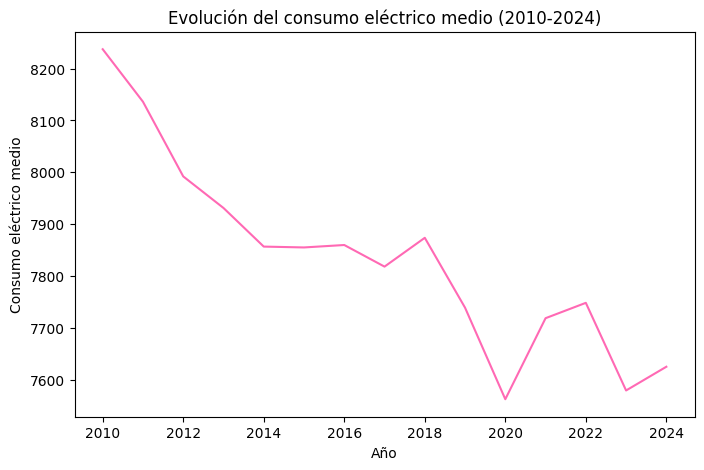

In [16]:
import matplotlib.pyplot as plt

# Filtramos electricidad
df_elec_all = df[df["indicator"] == "EG.USE.ELEC.KH.PC"]

# Media por año
electricity_year = df_elec_all.groupby("year")["value"].mean()

# color rosa
pink_color = "#ff69b4"

plt.figure(figsize=(8,5))

plt.plot(
    electricity_year.index,
    electricity_year.values,
    color=pink_color
)

plt.title("Evolución del consumo eléctrico medio (2010-2024)")
plt.xlabel("Año")
plt.ylabel("Consumo eléctrico medio")

plt.show()

## PASO 6: Cargar resultados a base de datos SQL

In [ ]:
# Importamos SQLAlchemy para conectar con base de datos
from sqlalchemy import create_engine

# Creamos base de datos SQLite local
engine = create_engine("sqlite:///world_bank_analysis.db")

# Vamos a guardar cada DataFrame en una tabla distinta

# TABLA 1: POBLACIÓN
df_population.to_sql(
    "indicator_population",
    engine,
    if_exists="replace",
    index=False
)

# TABLA 2: ALFABETIZACIÓN
df_literacy.to_sql(
    "indicator_literacy",
    engine,
    if_exists="replace",
    index=False
)

# TABLA 3: ELECTRICIDAD
df_electricity.to_sql(
    "indicator_electricity",
    engine,
    if_exists="replace",
    index=False
)

# TABLA 4: SALUD
df_health.to_sql(
    "indicator_health",
    engine,
    if_exists="replace",
    index=False
)


# Aquí comprobamos que los datos se han guardado bien
pd.read_sql(
    "SELECT * FROM indicator_population LIMIT 5",
    engine
)

,country,year,indicator,value
0,Argentina,2024,SP.POP.TOTL,45696159.0
1,Argentina,2023,SP.POP.TOTL,45538401.0
2,Argentina,2022,SP.POP.TOTL,45407904.0
3,Argentina,2021,SP.POP.TOTL,45312281.0
4,Argentina,2020,SP.POP.TOTL,45191965.0
